In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.filters.hp_filter import hpfilter
import json

In [25]:
with open('params.json') as f:
    p = json.load(f)

data_quarterly = pd.read_excel("..//data/DataParametrization.xlsx", 
                               sheet_name="Quarterly",
                               index_col="date")

for col in ['tot', 'px', 'pm', 'X', 'M', 'Y']:
    data_quarterly[col] = pd.to_numeric(data_quarterly[col], errors='coerce')


data_quarterly = data_quarterly.dropna(how='all', axis=0)
data_monthly = pd.read_excel("..//data/DataParametrization.xlsx", sheet_name="Monthly", index_col="date")

In [26]:
np.log(pd.to_numeric(data_monthly['exrate'].resample('Q').mean(), errors='coerce')).var()

/var/folders/1r/dljp1t4x41s3x_drvfz6xvbc0000gn/T/ipykernel_30591/2026981687.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  np.log(pd.to_numeric(data_monthly['exrate'].resample('Q').mean(), errors='coerce')).var()


np.float64(0.012043255477057722)

In [27]:
# compute quarterly std of log changes in exrate from monthly data
ln_ex_m = np.log(pd.to_numeric(data_monthly['exrate'].resample('Q').mean(), errors='coerce')).dropna()
ln_ex_q = ln_ex_m
dq = ln_ex_q.diff().dropna() 
sigma_ex_q = dq.var()

print(f'std quarterly ln(exrate_t+1) - ln(exrate_t): {sigma_ex_q:.6f}')
p['sigma_e'] = round(float(sigma_ex_q), 6)

std quarterly ln(exrate_t+1) - ln(exrate_t): 0.000525


/var/folders/1r/dljp1t4x41s3x_drvfz6xvbc0000gn/T/ipykernel_30591/196500918.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ln_ex_m = np.log(pd.to_numeric(data_monthly['exrate'].resample('Q').mean(), errors='coerce')).dropna()


<Axes: xlabel='date'>

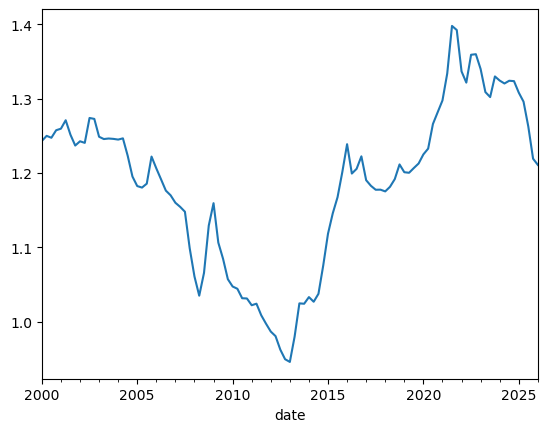

In [28]:
ln_ex_q.plot.line()

gamma (import share): 0.2696
gamma (avg trade share): 0.2640


<Axes: xlabel='date'>

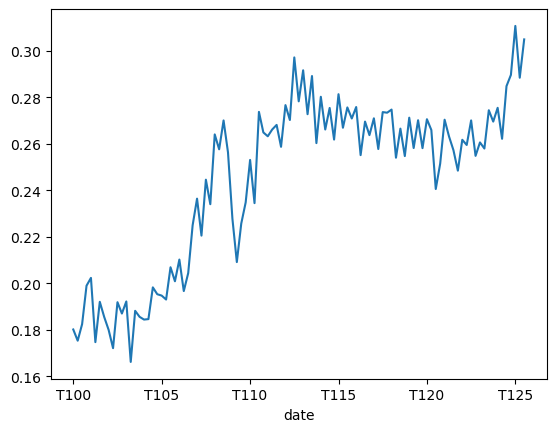

In [29]:
gamma_xm    = ((data_quarterly.X + data_quarterly.M)/(2*data_quarterly.Y))[44:].mean() # Openness measure
gamma_m     = (data_quarterly.M/data_quarterly.Y)[44:].mean() # Consumption on tradables share
p["gamma"]  = round(gamma_m, 4)

# T111 [44:]

print(f'gamma (import share): {gamma_m:.4f}')
print(f'gamma (avg trade share): {gamma_xm:.4f}')

(data_quarterly.M/data_quarterly.Y).plot.line()

<Axes: xlabel='date'>

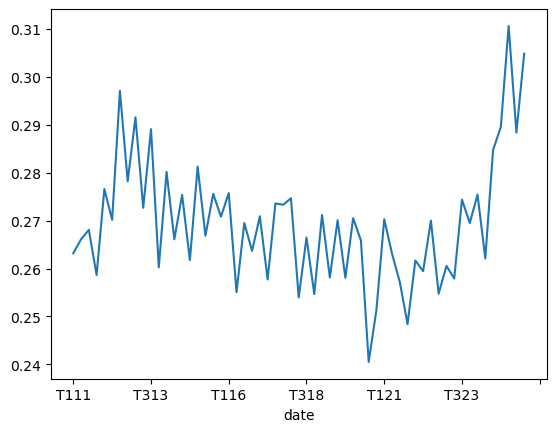

In [30]:
(data_quarterly.M/data_quarterly.Y)[44:].plot.line()

In [31]:
tot        = np.log(1/data_quarterly.tot.astype(float)).dropna()
tot_cycle, tot_trend = hpfilter(tot, lamb=1600)
tot_demean = tot - tot.mean()

ar_q = AutoReg(tot_cycle, lags=1).fit()
rho_q = ar_q.params.iloc[1]
sigma_q = np.std(ar_q.resid)

print(f'rho_q = {rho_q:.4f}')
print(f'sigma_q = {sigma_q:.6f}')

p['rho_q'] = round(float(rho_q), 4)
p['sigma_q'] = round(float(sigma_q), 6)

rho_q = 0.8368
sigma_q = 0.038368


/opt/homebrew/Caskroom/miniforge/base/envs/lab/lib/python3.14/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/homebrew/Caskroom/miniforge/base/envs/lab/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/opt/homebrew/Caskroom/miniforge/base/envs/lab/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/var/folders/1r/dljp1t4x41s3x_drvfz6xvbc0000gn/T/ipykernel_30591/429000746.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ln_ex_q = np.log(pd.to_numeric(data_monthly['exrate'].resample('Q').mean(), errors='coerce')).dropna()
/opt/homebrew/Caskroom/miniforge/base/envs/lab/lib/python3.14/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


N obs:                       101
Pass-through beta:           0.1237
R-squared:                   0.0522
rho_q:                       0.8368
sigma_q:                     0.004747
Unconditional Std(q_tilde):  0.008670
Std(Delta log e) data:       0.022462


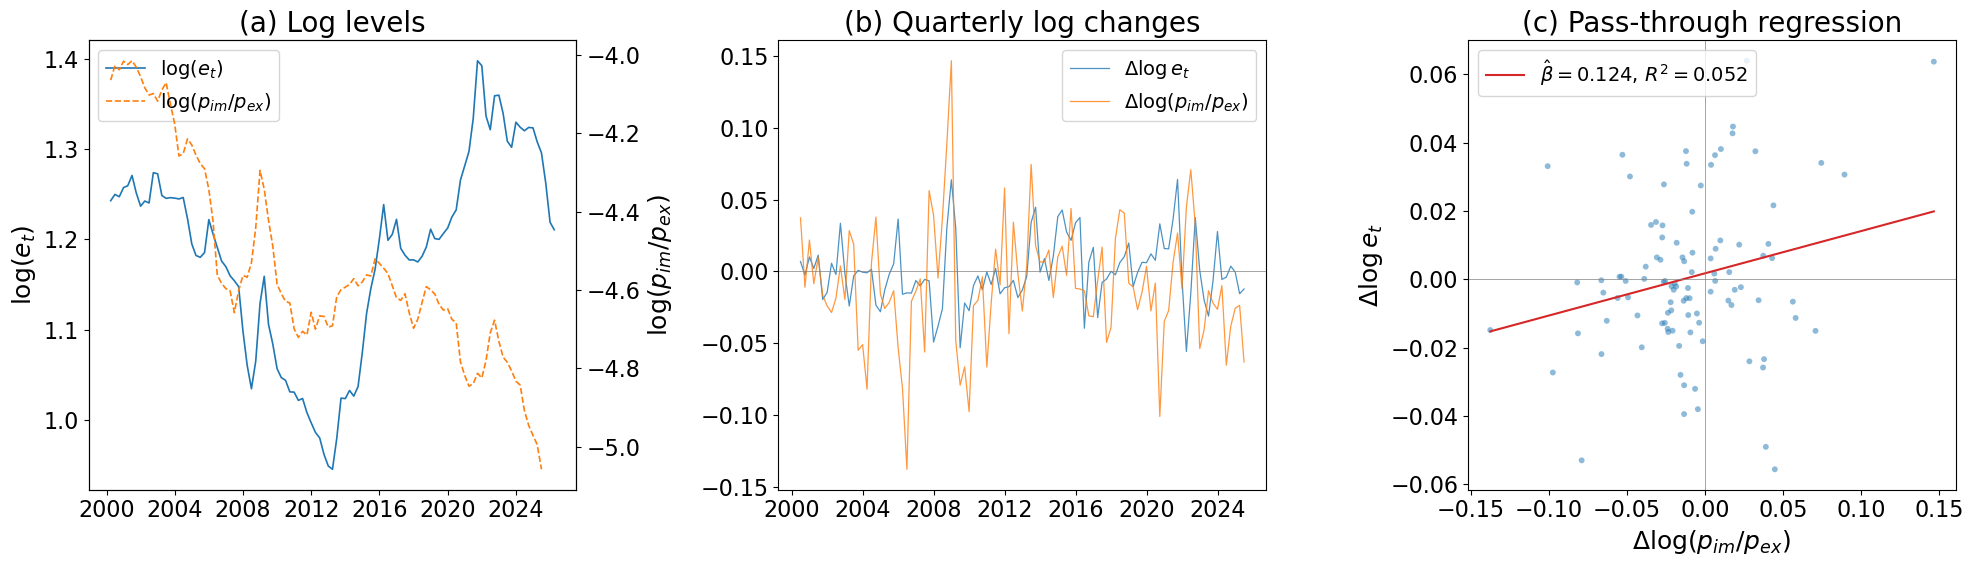

In [58]:
# ── Exchange rate ──────────────────────────────────────────────────────────
ln_ex_q = np.log(pd.to_numeric(data_monthly['exrate'].resample('Q').mean(), errors='coerce')).dropna()
dq_e_series = ln_ex_q.diff().dropna()

# ── ToT ────────────────────────────────────────────────────────────────────
tot = np.log(1 / data_quarterly.tot.astype(float)).dropna()
dq_tot_series = pd.Series(np.diff(tot.values), index=tot.index[1:])

def tcode_to_datetime(t):
    """Convert T100 format to datetime. T100 = 2000Q1, T200 = 2000Q2, etc."""
    q = int(t[1])  # quarter
    yy = int(t[2:])  # two-digit year
    year = 2000 + yy
    month = {1: 3, 2: 6, 3: 9, 4: 12}[q]
    return pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)

dq_tot_series.index = pd.DatetimeIndex([tcode_to_datetime(t) for t in dq_tot_series.index])
tot.index = pd.DatetimeIndex([tcode_to_datetime(t) for t in tot.index])

# Align to same dates
common_idx = dq_e_series.index.intersection(dq_tot_series.index)
dq_e_series = dq_e_series.loc[common_idx]
dq_tot_series = dq_tot_series.loc[common_idx]

dq_e = dq_e_series.values
dq_tot = dq_tot_series.values
n = len(dq_e)

# ── Pass-through regression ────────────────────────────────────────────────
X   = sm.add_constant(dq_tot)
res = sm.OLS(dq_e, X).fit()
beta = res.params[1]

# ── rho_q from HP cycle ────────────────────────────────────────────────────
tot_full = np.log(1 / data_quarterly.tot.astype(float)).dropna().values
tot_cycle, _ = hpfilter(pd.Series(tot_full), lamb=1600)
rho_q = AutoReg(tot_cycle, lags=1).fit().params.iloc[1]

# ── sigma_q ────────────────────────────────────────────────────────────────
ar_resid_std = np.std(AutoReg(tot_cycle, lags=1).fit().resid)
sigma_q = abs(beta) * ar_resid_std

# ── Print results ──────────────────────────────────────────────────────────
print(f'N obs:                       {n}')
print(f'Pass-through beta:           {beta:.4f}')
print(f'R-squared:                   {res.rsquared:.4f}')
print(f'rho_q:                       {rho_q:.4f}')
print(f'sigma_q:                     {sigma_q:.6f}')
print(f'Unconditional Std(q_tilde):  {sigma_q / np.sqrt(1 - rho_q**2):.6f}')
print(f'Std(Delta log e) data:       {np.std(dq_e):.6f}')

p['rho_q']   = round(float(rho_q), 4)
p['sigma_q'] = round(float(sigma_q), 6)

# ── LaTeX regression table ─────────────────────────────────────────────────
se = res.bse
t_vals = res.tvalues

latex_table = rf"""
\begin{{table}}[H]
    \centering
    \begin{{singlespace}}
    \caption{{ToT pass-through: $\Delta \log e_t = \alpha + \beta \, \Delta \log (p_{{im}}/p_{{ex}})_t + \varepsilon_t$}}
    \label{{tab:tot_passthrough}}
    \begin{{tabular}}{{lc}}
        \toprule
        & $\Delta \log e_t$ \\
        \midrule
        $\alpha$ & {res.params[0]:.4f} \\
                  & ({se[0]:.4f}) \\[4pt]
        $\beta$   & {res.params[1]:.4f} \\
                  & ({se[1]:.4f}) \\
        \midrule
        $R^2$     & {res.rsquared:.4f} \\
        $N$       & {n} \\
        \bottomrule
    \end{{tabular}}

    \smallskip
    \centering
    \begin{{minipage}}{{0.5\linewidth}}
    \footnotesize
    \textit{{Notes:}} OLS estimates. Standard errors in parentheses.
    \end{{minipage}}
    \end{{singlespace}}
\end{{table}}
"""

with open('../paper/tables/tot_passthrough.tex', 'w') as f:
    f.write(latex_table)

# ── Plots ──────────────────────────────────────────────────────────────────
with plt.rc_context({'font.size': 18, 'axes.titlesize': 20, 'axes.labelsize': 18,
                      'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 14}):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # (a) Levels: log exrate and log(1/ToT)
    ax = axes[0]
    ax.plot(ln_ex_q.index, ln_ex_q.values, label=r'$\log(e_t)$', linewidth=1.2)
    ax2 = ax.twinx()
    ax2.plot(tot.index, tot.values, label=r'$\log(p_{im}/p_{ex})$',
             color='C1', linewidth=1.2, linestyle='--')
    ax.set_title('(a) Log levels')
    ax.set_ylabel(r'$\log(e_t)$')
    ax2.set_ylabel(r'$\log(p_{im}/p_{ex})$')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    # (b) First differences
    ax = axes[1]
    ax.plot(dq_e_series.index, dq_e_series.values, label=r'$\Delta \log e_t$', linewidth=0.9, alpha=0.8)
    ax.plot(dq_tot_series.index, dq_tot_series.values, label=r'$\Delta \log(p_{im}/p_{ex})$', linewidth=0.9, alpha=0.8)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_title('(b) Quarterly log changes')
    ax.legend()

    # (c) Scatter + regression
    ax = axes[2]
    ax.scatter(dq_tot, dq_e, s=18, alpha=0.5, edgecolors='none')
    xgrid = np.linspace(dq_tot.min(), dq_tot.max(), 100)
    ax.plot(xgrid, res.params[0] + res.params[1] * xgrid,
            color='C3', linewidth=1.5,
            label=rf'$\hat\beta = {beta:.3f}$, $R^2 = {res.rsquared:.3f}$')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_xlabel(r'$\Delta \log(p_{im}/p_{ex})$')
    ax.set_ylabel(r'$\Delta \log e_t$')
    ax.set_title('(c) Pass-through regression')
    ax.legend()

    plt.tight_layout()
    plt.savefig('../paper/figures/tot_passthrough.pdf', bbox_inches='tight')
    plt.show()

In [33]:
# Load VIX data
df_daily = pd.read_excel("../data/DataParametrization.xlsx", sheet_name="Daily")
df_daily.index = df_daily.date

# Parse Spanish dates
#month_map = {'Ene':1, 'Feb':2, 'Mar':3, 'Abr':4, 'May':5, 'Jun':6,
#             'Jul':7, 'Ago':8, 'Set':9, 'Oct':10, 'Nov':11, 'Dic':12}

def parse_date(s):
    if not isinstance(s, str) or len(s) != 7:
        return None
    day = int(s[:2])
    month = month_map[s[2:5]]
    year = 2000 + int(s[5:])
    return pd.Timestamp(year=year, month=month, day=day)

#dates = [parse_date(d) for d in df_daily.date]
dates = df_daily.date

#
vix_values = pd.to_numeric(df_daily.vix, errors='coerce')

vix_daily = pd.Series(vix_values.values, index=dates).dropna()

# Aggregate to quarterly
vix_q = vix_daily.resample('Q').mean()
log_vix = np.log(vix_q)
vix_log_change = log_vix.diff().dropna()

# HP filter
vix_cycle, vix_trend = hpfilter(vix_q, lamb=1600)

# AR(1)
ar_n = AutoReg(vix_cycle, lags=1).fit()
ar_n = AutoReg(vix_q, lags=1).fit()
rho_n = ar_n.params[1]
sigma_n = np.std(ar_n.resid)

print(f'rho_n = {rho_n:.4f}')
print(f'sigma_n = {sigma_n:.6f}')

p['rho_n'] = round(float(rho_n), 4)
p['sigma_n'] = round(float(sigma_n), 6)

rho_n = 0.7006
sigma_n = 5.249044


/var/folders/1r/dljp1t4x41s3x_drvfz6xvbc0000gn/T/ipykernel_30591/2690737424.py:26: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  vix_q = vix_daily.resample('Q').mean()
/opt/homebrew/Caskroom/miniforge/base/envs/lab/lib/python3.14/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/var/folders/1r/dljp1t4x41s3x_drvfz6xvbc0000gn/T/ipykernel_30591/2690737424.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rho_n = ar_n.params[1]


<Axes: xlabel='date'>

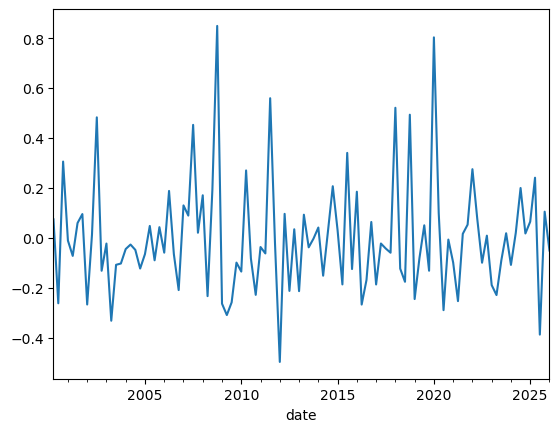

In [34]:
vix_log_change.plot.line()

(<Axes: xlabel='date'>, <Axes: xlabel='date'>, <Axes: xlabel='date'>)

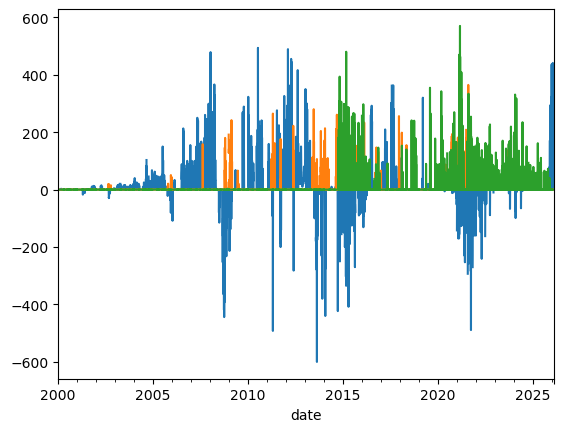

In [35]:
df_daily.fx_spot.plot.line(),df_daily.fx_cdr.plot.line(),df_daily.fx_swap.plot.line()

/var/folders/1r/dljp1t4x41s3x_drvfz6xvbc0000gn/T/ipykernel_30591/2528493109.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  fxi_quarterly = df_daily.fxi.resample('Q').sum()


fxi_mean = -0.0096
fxi_std = 0.125941
fxi_pos_mean = 0.0932
fxi_pos_std  = 0.090393
fxi_neg_mean = -0.0891
fxi_neg_std  = 0.095391


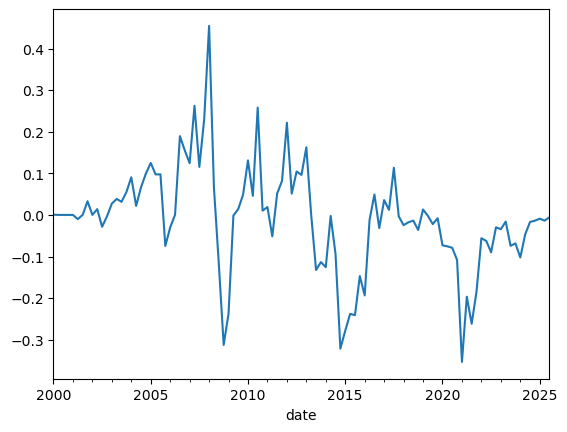

In [36]:
df_daily['fxi'] = df_daily.fx_spot - df_daily.fx_cdr - df_daily.fx_swap

fxi_quarterly = df_daily.fxi.resample('Q').sum()
#fxi_quarterly = fxi_quarterly[:-1]/(data_quarterly.Y_e.values)
fxi_quarterly = fxi_quarterly[:-2]/(data_quarterly.X.values[:-1] + data_quarterly.M.values[:-1])*(data_quarterly.Y.values[:-1]/data_quarterly.Y_e.values[:-1])
#fxi_quarterly = fxi_quarterly[:-2]/(data_quarterly.X.values[:-1] + data_quarterly.M.values[:-1])
fxi_quarterly = fxi_quarterly#*100
fxi_quarterly.plot.line()

fxi_mean = fxi_quarterly.mean()
fxi_std  = fxi_quarterly.std()

print(f'fxi_mean = {fxi_mean:.4f}')
print(f'fxi_std = {fxi_std:.6f}')

p['fxi_mean'] = round(float(fxi_mean), 4)
p['fxi_std'] = round(float(fxi_std), 6)

# Positive FXI (purchases / leaning against appreciation)
fxi_pos = fxi_quarterly[fxi_quarterly > 0]
fxi_pos_mean = fxi_pos.mean()
fxi_pos_std  = fxi_pos.std()
print(f'fxi_pos_mean = {fxi_pos_mean:.4f}')
print(f'fxi_pos_std  = {fxi_pos_std:.6f}')

# Negative FXI (sales / leaning against depreciation)
fxi_neg = fxi_quarterly[fxi_quarterly < 0]
fxi_neg_mean = fxi_neg.mean()
fxi_neg_std  = fxi_neg.std()
print(f'fxi_neg_mean = {fxi_neg_mean:.4f}')
print(f'fxi_neg_std  = {fxi_neg_std:.6f}')

p['fxi_pos_mean'] = round(float(fxi_pos_mean), 4)
p['fxi_pos_std']  = round(float(fxi_pos_std), 6)
p['fxi_neg_mean'] = round(float(fxi_neg_mean), 4)
p['fxi_neg_std']  = round(float(fxi_neg_std), 6)

In [37]:
fxi_quarterly[-24:]

date
2019-12-31   -0.008044
2020-03-31   -0.073089
2020-06-30   -0.075574
2020-09-30   -0.079059
2020-12-31   -0.108331
2021-03-31   -0.353368
2021-06-30   -0.196733
2021-09-30   -0.261604
2021-12-31   -0.183937
2022-03-31   -0.056041
2022-06-30   -0.062519
2022-09-30   -0.089946
2022-12-31   -0.029812
2023-03-31   -0.034301
2023-06-30   -0.016055
2023-09-30   -0.074345
2023-12-31   -0.068471
2024-03-31   -0.102329
2024-06-30   -0.047111
2024-09-30   -0.016914
2024-12-31   -0.013833
2025-03-31   -0.009083
2025-06-30   -0.013654
2025-09-30   -0.005829
Freq: QE-DEC, Name: fxi, dtype: float64

<Axes: xlabel='date'>

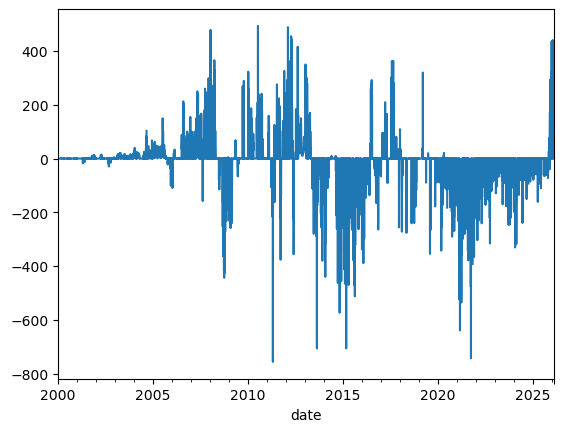

In [38]:
df_daily['fxi'].plot.line()

In [39]:
#####################
# Update params.json
#####################

with open('params.json', 'w') as f:
    json.dump(p, f, indent=4)